<a href="https://colab.research.google.com/github/naldonymous/IMDB-Sentiment-Analysis-Project/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMDB Sentiment Analysis
Install datasets and wordcloud libraries.

In [1]:
!pip install datasets wordcloud

Imports all the required libraries, with "Phases" labelled.

In [2]:
# Phase I
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from wordcloud import WordCloud
# Phase II
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
# Phase III
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
# Phase IV
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

Loads the IMDB dataset, and makes data frames out of pre-labelled "training" and "testing" data.

In [3]:
datasets = load_dataset("imdb")
df_train = pd.DataFrame(datasets["train"])
df_test = pd.DataFrame(datasets["test"])
print(df_train.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0


Bar graph of amount of positive and negative reviews, amounts seem to be about equal, which is good.

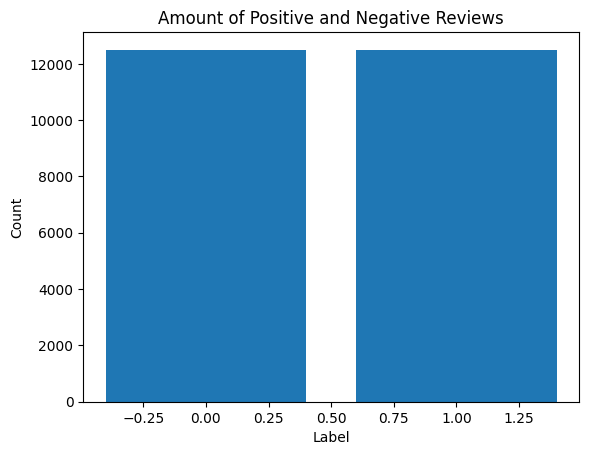

In [4]:
counts = df_train.value_counts('label')
plt.bar(counts.index, counts.values)
plt.title('Amount of Positive and Negative Reviews')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

Histogram of length of reviews. Most seem to be within 0-4000 characters.

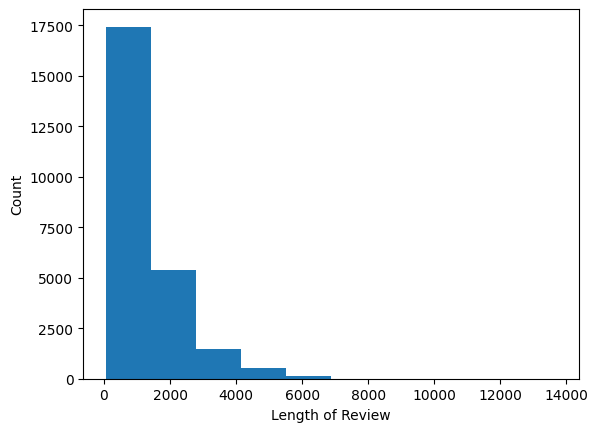

In [5]:
df_train['length'] = df_train['text'].apply(len)

plt.hist(df_train.length)
plt.xlabel('Length of Review')
plt.ylabel('Count')
plt.show()

Makes word clouds for "positive" and "negative" reviews.

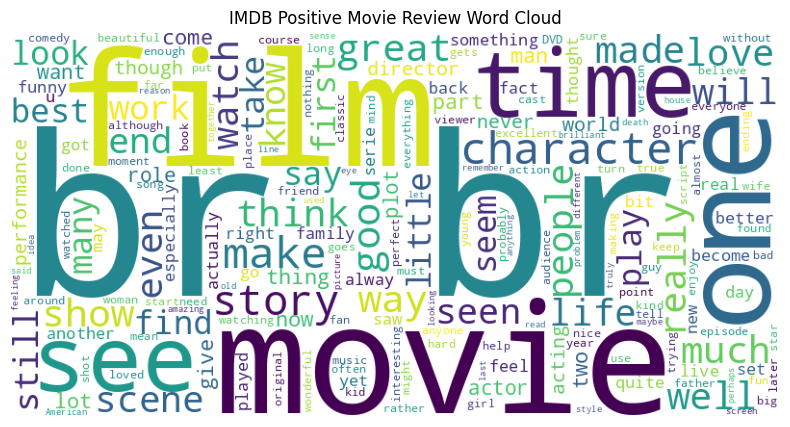

In [6]:
df_tpositive = df_train[df_train['label'] == 1]
df_tnegative = df_train[df_train['label'] == 0]

positive_text = "".join(df_tpositive['text'])
negative_text = "".join(df_tnegative['text'])

positiveWordCloud = WordCloud(width = 800, height = 400, background_color = 'white').generate(positive_text)
plt.figure(figsize=(10, 5))
plt.imshow(positiveWordCloud)
plt.axis('off')
plt.title("IMDB Positive Movie Review Word Cloud")
plt.show()

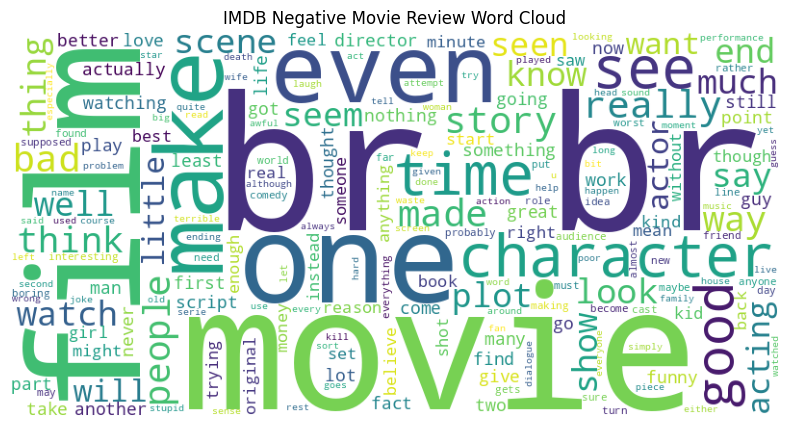

In [7]:
negativeWordCloud = WordCloud(width = 800, height = 400, background_color = 'white').generate(negative_text)
plt.figure(figsize=(10, 5))
plt.imshow(negativeWordCloud)
plt.axis('off')
plt.title("IMDB Negative Movie Review Word Cloud")
plt.show()

Makes training and testing sets.

In [8]:
X_train = df_train['text']
y_train = df_train['label']
X_test = df_test['text']
y_test = df_test['label']

Vectorizes data for fitting later on.

In [9]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Logistic regression on data.

In [10]:
logRegression = LogisticRegression()

logRegression.fit(X_train_tfidf, y_train)
y_pred = logRegression.predict(X_test_tfidf)

Finds accuracy score and makes classification report for logistic regression, accuracy is 0.88292.

In [11]:
accuracy_score(y_test, y_pred)

0.88292

In [12]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.88      0.88      0.88     12500\n           1       0.88      0.88      0.88     12500\n\n    accuracy                           0.88     25000\n   macro avg       0.88      0.88      0.88     25000\nweighted avg       0.88      0.88      0.88     25000\n'

Multinomial Naive Bayes on data.

In [13]:
multinomial_model = MultinomialNB()

multinomial_model.fit(X_train_tfidf, y_train)
y_pred_multinomial = multinomial_model.predict(X_test_tfidf)

Linear SVC (Support Vector Classifier) on data.

In [14]:
linear_svc_model = LinearSVC()

linear_svc_model.fit(X_train_tfidf, y_train)
y_pred_linear_svc = linear_svc_model.predict(X_test_tfidf)

Finds accuracy scores for Multinomial Naive Bayes and Linear SVC.

In [15]:
accuracy_score(y_test, y_pred_multinomial)

0.82956

In [16]:
accuracy_score(y_test, y_pred_linear_svc)

0.8772

So, logistic regression had the highest accuracy score, but now we can tune it using GridSearchCV.

In [17]:
param_grid = {"C": [0.01, 0.1, 1, 10, 100]}

In [18]:
gridSearch = GridSearchCV(logRegression, param_grid, cv = 5)
gridSearch.fit(X_train_tfidf, y_train)
gridSearch.best_params_

{'C': 1}

In [19]:
model = LogisticRegression(C=1)
model.fit(X_train_tfidf, y_train)
y_pred_model = model.predict(X_test_tfidf)
accuracy_score(y_test, y_pred_model)

0.88292

## Conclusion
Best model is logistic regresssion with normal parameters, accuracy was 88.292%.

## ROC Curve

In [20]:
y_prob = model.predict_proba(X_test_tfidf)[:, 1]

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

In [22]:
auc

np.float64(0.952797088)

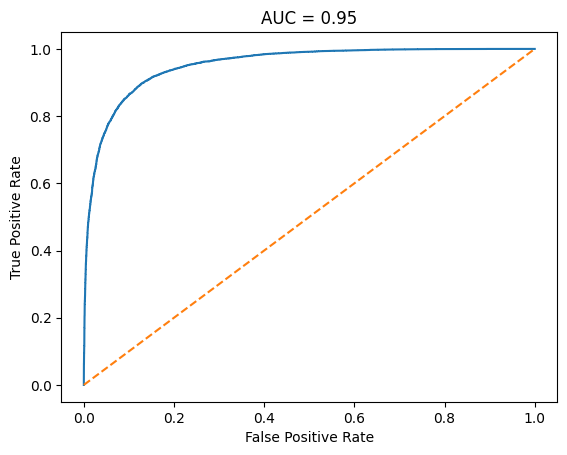

In [23]:
plt.plot(fpr, tpr)
plt.title(f"AUC = {auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.plot([0, 1], [0, 1], '--')